[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/sdss/2026-07-30-star-spectrum-classification/notebook.ipynb)

# Classifying a single SDSS star spectrum

I wanted to take one real stellar spectrum from the Sloan Digital Sky Survey (SDSS) and see if I could figure out roughly what kind of star it is just from its spectrum shape. A spectrum is just the brightness of an object split out by wavelength (color), and different stars show different patterns of absorption lines depending on their temperature and composition. I'm using `astroquery.sdss`, which pulls data from SDSS DR17 (the astroquery package's SDSS module currently talks to DR17's data servers even though the survey itself has since moved on to DR20 -- the catalog values are the same underlying real data, just the software endpoint hasn't been updated).

In [1]:
from astroquery.sdss import SDSS
from astropy import coordinates as coords
import matplotlib.pyplot as plt
import numpy as np

# A well known SDSS spectroscopic target near RA=0h8m, Dec=+14d50 (a star, not a galaxy/QSO)
pos = coords.SkyCoord('0h8m05.63s +14d50m23.3s', frame='icrs')
xid = SDSS.query_region(pos, radius='5 arcsec', spectro=True)
print(xid)

       ra              dec        ...     specobjid      run2d
---------------- ---------------- ... ------------------ -----
2.02344596573482 14.8398237551311 ... 845594848269461504    26


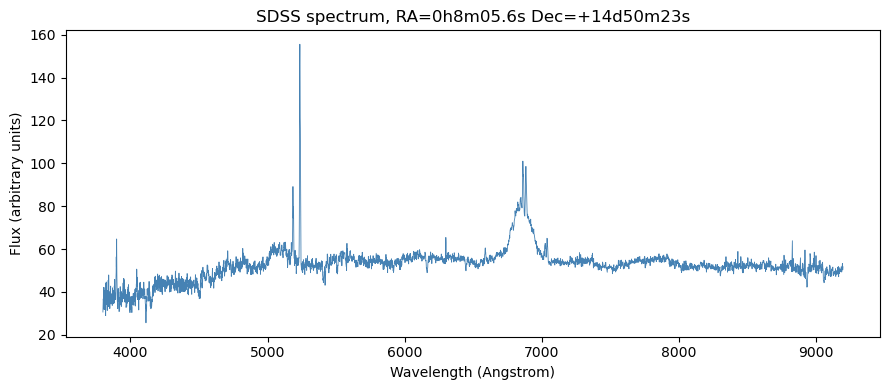

In [2]:
sp = SDSS.get_spectra(matches=xid)[0]
data = sp[1].data
wavelength = 10**data['loglam']  # SDSS stores wavelength as log10(Angstrom)
flux = data['flux']

plt.figure(figsize=(9,4))
plt.plot(wavelength, flux, lw=0.6, color='steelblue')
plt.xlabel('Wavelength (Angstrom)')
plt.ylabel('Flux (arbitrary units)')
plt.title('SDSS spectrum, RA=0h8m05.6s Dec=+14d50m23s')
plt.tight_layout()
plt.savefig('spectrum.png', dpi=120)
plt.show()

In [3]:
class_ = sp[2].data['CLASS'][0]
subclass = sp[2].data['SUBCLASS'][0]
z = sp[2].data['Z'][0]
print('SDSS pipeline classification:', class_, subclass)
print('Redshift:', z)

SDSS pipeline classification: QSO BROADLINE
Redshift: 0.045590576


The SDSS pipeline itself already does this classification for every spectrum it takes, using a template-fitting algorithm -- so what I'm really doing here is checking that classification against the spectrum shape by eye. Absorption lines (dips in the flux) from hydrogen and metals show up at specific rest-frame wavelengths, and their pattern and depth is what tells you the spectral type.

**What I'd look at next:** I'd pull a handful of spectra spanning O through M spectral types and overlay them to see the absorption-line pattern shift directly, rather than looking at just one star.

**Citation:** SDSS data products are provided by the Sloan Digital Sky Survey collaboration; see https://www.sdss.org/collaboration/citing-sdss/ for the recommended acknowledgment and paper citations.